In [2]:
import numpy as np
import os
import csv
import networkx as nx
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

import generate_graph
import play_greedy

In [12]:
EMBEDDING_FILE = "data/embeddings.pkl"
OUTPUT_CSV = "data/greedy_results.csv"
K_VALUES = range(10, 45, 5)
K_RANDOM = 5
NUM_GAMES = 100

def run_experiment():
    words, vectors = generate_graph.load_vectors(EMBEDDING_FILE)
    embeddings_dict = {w: v for w, v in zip(words, vectors)}    
    avg_diffs = []
    
    print(f"Starting simulation on {len(words)} words...")
    print(f"Logging results to: {OUTPUT_CSV}")

    # Open CSV in append mode
    with open(OUTPUT_CSV, mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        
        if not os.path.exists(OUTPUT_CSV):
            headers = ["k_nn", "k_random", "start_word", "target_word", "success", "ai_path_len", "optimal_len", "diff"]
            writer.writerow(headers)

        # 2. Iterate through K values
        for k in K_VALUES:
            
            # --- Dynamic Graph Rebuilding ---
            # We override the global variables in the imported module 
            # to force it to build with our specific parameters
            generate_graph.K = k
            generate_graph.K_RANDOM = K_RANDOM
            
            # Build the graph (this might take a moment per K)
            G = generate_graph.build_small_world(words, vectors)
            nodes = list(G.nodes())
            
            current_k_diffs = []
            
            # 3. Play Games
            for _ in tqdm(range(NUM_GAMES), desc=f"  Simulating"):
                # A. Find valid start/end pair
                while True:
                    start, target = random.sample(nodes, 2)
                    try:
                        optimal_path = nx.shortest_path(G, start, target)
                        optimal_len = len(optimal_path) - 1
                        # Only play if optimal path is at least 2 steps (non-trivial)
                        if optimal_len >= 2: 
                            break
                    except nx.NetworkXNoPath:
                        continue

                # B. AI Plays
                success, ai_path = play_greedy.play_game(G, embeddings_dict, start, target)
                
                # C. Calculate Stats
                if success:
                    ai_len = len(ai_path) - 1
                    diff = ai_len - optimal_len
                    current_k_diffs.append(diff)
                else:
                    ai_len = -1 # Indicator for failure
                    diff = -1
                
                # D. Log to CSV
                # Columns: k_nn, k_random, start, target, success, ai_len, opt_len, diff
                writer.writerow([k, K_RANDOM, start, target, success, ai_len, optimal_len, diff])

            # Store average for plotting
            if current_k_diffs:
                avg_diffs.append(np.mean(current_k_diffs))
            else:
                avg_diffs.append(0)

    return list(K_VALUES), avg_diffs

In [13]:
k_vals, y_vals = run_experiment()

Starting simulation on 9929 words...
Logging results to: data/greedy_results.csv
0. Normalizing vectors for fast distance calculation...
1. Finding 10 nearest neighbors for 9929 words...
2. Building Directed Graph (10 NN + 5 Random edges per node)...
   Processed 1000/9929 nodes...
   Processed 2000/9929 nodes...
   Processed 3000/9929 nodes...
   Processed 4000/9929 nodes...
   Processed 5000/9929 nodes...
   Processed 6000/9929 nodes...
   Processed 7000/9929 nodes...
   Processed 8000/9929 nodes...
   Processed 9000/9929 nodes...


  Simulating: 100%|██████████| 100/100 [00:10<00:00,  9.38it/s]


0. Normalizing vectors for fast distance calculation...
1. Finding 15 nearest neighbors for 9929 words...
2. Building Directed Graph (15 NN + 5 Random edges per node)...
   Processed 1000/9929 nodes...
   Processed 2000/9929 nodes...
   Processed 3000/9929 nodes...
   Processed 4000/9929 nodes...
   Processed 5000/9929 nodes...
   Processed 6000/9929 nodes...
   Processed 7000/9929 nodes...
   Processed 8000/9929 nodes...
   Processed 9000/9929 nodes...


  Simulating: 100%|██████████| 100/100 [00:06<00:00, 14.55it/s]


0. Normalizing vectors for fast distance calculation...
1. Finding 20 nearest neighbors for 9929 words...
2. Building Directed Graph (20 NN + 5 Random edges per node)...
   Processed 1000/9929 nodes...
   Processed 2000/9929 nodes...
   Processed 3000/9929 nodes...
   Processed 4000/9929 nodes...
   Processed 5000/9929 nodes...
   Processed 6000/9929 nodes...
   Processed 7000/9929 nodes...
   Processed 8000/9929 nodes...
   Processed 9000/9929 nodes...


...

  Simulating: 100%|██████████| 100/100 [00:05<00:00, 16.75it/s]


0. Normalizing vectors for fast distance calculation...
1. Finding 35 nearest neighbors for 9929 words...
2. Building Directed Graph (35 NN + 5 Random edges per node)...
   Processed 1000/9929 nodes...
   Processed 2000/9929 nodes...
   Processed 3000/9929 nodes...
   Processed 4000/9929 nodes...
   Processed 5000/9929 nodes...
   Processed 6000/9929 nodes...
   Processed 7000/9929 nodes...
   Processed 8000/9929 nodes...
   Processed 9000/9929 nodes...


  Simulating: 100%|██████████| 100/100 [00:06<00:00, 15.02it/s]


0. Normalizing vectors for fast distance calculation...
1. Finding 40 nearest neighbors for 9929 words...
2. Building Directed Graph (40 NN + 5 Random edges per node)...
   Processed 1000/9929 nodes...
   Processed 2000/9929 nodes...
   Processed 3000/9929 nodes...
   Processed 4000/9929 nodes...
   Processed 5000/9929 nodes...
   Processed 6000/9929 nodes...
   Processed 7000/9929 nodes...
   Processed 8000/9929 nodes...
   Processed 9000/9929 nodes...


  Simulating: 100%|██████████| 100/100 [00:07<00:00, 13.44it/s]


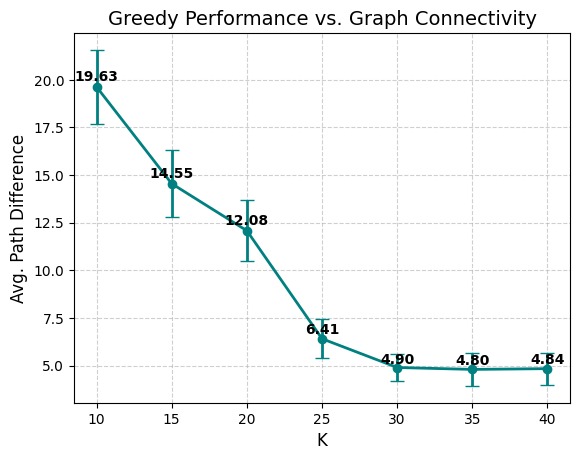

In [11]:
greedy_results = pd.read_csv("data/greedy_results.csv")
greedy_results['diff'] = greedy_results['diff'].replace(-1, 50)
plot_data = greedy_results.groupby('k_nn')['diff'].mean()
plot_errors = greedy_results.groupby('k_nn')['diff'].sem()

plt.errorbar(x=plot_data.index, 
             y=plot_data.values, 
             yerr=plot_errors.values, 
             fmt='-o',
             color='teal',
             linewidth=2, 
             markersize=6,
             capsize=5,
             label='Mean Diff')

for x, y in zip(plot_data.index, plot_data.values):
    plt.text(x, y + 0.15 + (plot_errors[x] * 0.1),
             f'{y:.2f}',
             ha='center',
             fontweight='bold', 
             color='black')

plt.title('Greedy Performance vs. Graph Connectivity', fontsize=14)
plt.xlabel('K', fontsize=12)
plt.ylabel('Avg. Path Difference', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [12]:
human_results = pd.read_csv("data/human_results.csv")
human_results['diff'] = human_results['diff'].replace(-1, 50)
plot_data = human_results.groupby('k_nn')['diff'].mean()
plot_errors = human_results.groupby('k_nn')['diff'].sem()

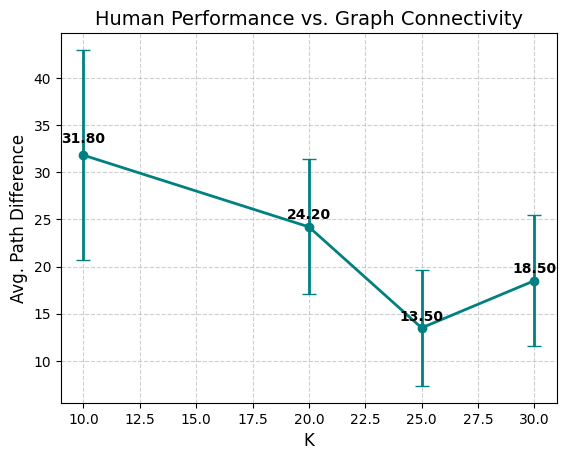

In [13]:
plt.errorbar(x=plot_data.index, 
             y=plot_data.values, 
             yerr=plot_errors.values, 
             fmt='-o',
             color='teal',
             linewidth=2, 
             markersize=6,
             capsize=5,
             label='Mean Diff')

for x, y in zip(plot_data.index, plot_data.values):
    plt.text(x, y + 0.15 + (plot_errors[x] * 0.1),
             f'{y:.2f}',
             ha='center',
             fontweight='bold', 
             color='black')

plt.title('Human Performance vs. Graph Connectivity', fontsize=14)
plt.xlabel('K', fontsize=12)
plt.ylabel('Avg. Path Difference', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()